In [1]:
import os
import sys
from pathlib import Path

# Add src/ to sys.path so the local euroqol package can be imported without installation
library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
from euroqol.utils import compute_smd

## Within-HSE Consistency Check: HSE 2017 vs HSE 2018

### Rationale

The norm derivation pipeline (notebook 04) uses **HSE 2017 and HSE 2018** as the
reference/target distribution. HSE 2019 is excluded because it has no EQ-5D-5L outcome
data. Before deriving norms, we need to verify that these two waves are internally
consistent — i.e., that pooling them as a single reference does not introduce
artefactual distributional shift.

This check uses the **17-variable predictor set** for notebook 04, which extends the
13-variable set from notebook 03 by adding `resp`, `skin`, `paVig`, and `paMod`
(all 0% missing in HSE 2017–18 and DAPHNIE 2024 once HSE 2019 is excluded from the target).
`paVig` and `paMod` are ordinal-encoded: `'<2'` → 1, `'1-2 days'` → 2, `'3+ days'` → 3.

The standard threshold for meaningful imbalance is $|\text{SMD}| > 0.1$. Variables
exceeding this between 2017 and 2018 would indicate wave-specific composition effects
that should be acknowledged when interpreting the pooled reference norms.

SMD is computed as (HSE 2018 − HSE 2017), using survey weights (`wt_int`) for both
waves. Positive values indicate higher prevalence/mean in 2018.


In [4]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse17 = df[df["dataset"] == "HSE 2017"].copy()
hse18 = df[df["dataset"] == "HSE 2018"].copy()
hse22 = df[df["dataset"] == "HSE 2022"].copy()

print(f"HSE 2017: n = {len(hse17):,}")
print(f"HSE 2018: n = {len(hse18):,}")

HSE 2017: n = 7,840
HSE 2018: n = 7,990


In [5]:
# 17-variable predictor set for notebook 04
# 13 from notebook 03 (confirmed by PI) + resp + skin + paVig + paMod
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

# Confirm no missing values in either wave
print("\nMissingness check:")
miss = pd.DataFrame({
    "HSE 2017 miss%": hse17[ALL_FEATURES].isna().mean() * 100,
    "HSE 2018 miss%": hse18[ALL_FEATURES].isna().mean() * 100,
}).round(1)
display(miss[miss.max(axis=1) > 0] if (miss.max(axis=1) > 0).any() else "No missing values in either wave.")

# Also report dtypes so non-numeric columns are immediately visible
print("\nColumn dtypes:")
print(df[ALL_FEATURES].dtypes.to_string())


Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']

Missingness check:


,HSE 2017 miss%,HSE 2018 miss%
eth2cat,0.400,0.300
edu_cat_2,0.500,0.600
meds_num,34.700,40.800
paVig,12.000,13.200
paMod,10.600,12.700



Column dtypes:
Sex                              float64
age7cat                          float64
eth2cat                          float64
emp_cat_Employed                 float64
emp_cat_Other (Sick/Home/etc)    float64
emp_cat_Retired                  float64
emp_cat_Student                  float64
emp_cat_Unemployed               float64
edu_cat_2                        float64
smoke_ecig                         int64
diabetes                           int64
meds_num                         float64
ill_dis                          float64
paVig                            float64
paMod                            float64
resp                             float64
skin                             float64


In [6]:
# Extract survey weights for each wave.
# Missing weights are filled with 1.0, treating those respondents as self-weighting
# (consistent with how other notebooks handle occasional weight missingness in HSE).
wt17 = hse17["wt_int"].fillna(1.0)
wt18 = hse18["wt_int"].fillna(1.0)
wt22 = hse22["wt_int"].fillna(1.0)


## Comparison between HSE 2017 and HSE 2018

This is the primary pooling validity check. Both waves share the same survey design and
sampling frame, so any large SMD here would indicate genuine wave-specific composition
differences that undermine pooling as a reference. All variables are expected to be
well-balanced ($|\text{SMD}| < 0.1$).


In [7]:
smds = {
    col: compute_smd(hse18[col], wt18, hse17[col], wt17)
    for col in ALL_FEATURES
}

smd_series = (
    pd.Series(smds, name="SMD (2018 − 2017)")
    .sort_values(key=abs, ascending=False)
)

print("SMD table (positive = higher in HSE 2018 than HSE 2017):")
display(smd_series.round(3).to_frame())

SMD table (positive = higher in HSE 2018 than HSE 2017):


,SMD (2018 − 2017)
eth2cat,0.047
emp_cat_Student,0.043
emp_cat_Employed,-0.026
emp_cat_Other (Sick/Home/etc),0.018
paVig,-0.018
edu_cat_2,-0.017
diabetes,0.016
smoke_ecig,0.013
paMod,0.012
ill_dis,-0.012


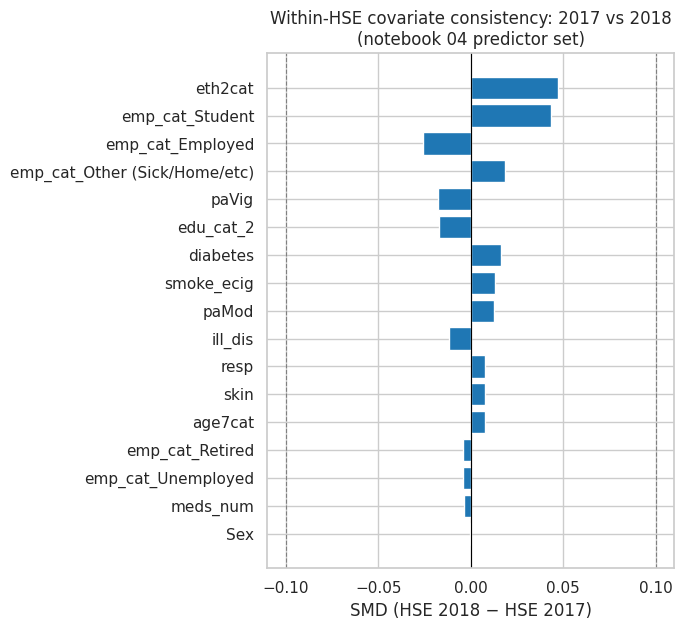

In [8]:
smds_plot = smd_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(7, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (HSE 2018 − HSE 2017)")
ax.set_title("Within-HSE covariate consistency: 2017 vs 2018\n(notebook 04 predictor set)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_hse_2017_vs_2018.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
valid = smd_series.dropna()
imbalanced = valid[valid.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(valid)}")

if len(imbalanced) == 0:
    print("\nAll predictor variables are well-balanced between HSE 2017 and HSE 2018.")
    print("Pooling the two waves as a single reference distribution for notebook 04 is supported.")
else:
    print("\nVariables exceeding |SMD| > 0.1 between HSE 2017 and HSE 2018:")
    display(imbalanced.round(3).to_frame())
    print("\nThese wave-specific differences should be acknowledged when interpreting")
    print("the pooled reference norms derived in notebook 04.")

Variables with |SMD| > 0.1: 0 / 17

All predictor variables are well-balanced between HSE 2017 and HSE 2018.
Pooling the two waves as a single reference distribution for notebook 04 is supported.


## Comparison between HSE 2018 and HSE 2022

This is a supplementary check using HSE 2022 as a later-wave reference. Note that
**HSE 2022 has no EQ-5D-5L data**, so it cannot be used for norm derivation; this
comparison is included purely to characterise secular trends in the predictor variables
across the wider HSE time series. Variables missing from HSE 2022 will produce `NaN`
SMDs and be excluded from the plot.


In [10]:
smds_18_22 = {
    col: compute_smd(hse18[col], wt18, hse22[col], wt22)
    for col in ALL_FEATURES
}

smd_series = (
    pd.Series(smds_18_22, name="SMD (2018 − 2022)")
    .sort_values(key=abs, ascending=False)
)

print("SMD table (positive = higher in HSE 2018 than HSE 2022):")
display(smd_series.round(3).to_frame())

SMD table (positive = higher in HSE 2018 than HSE 2022):


,SMD (2018 − 2022)
edu_cat_2,-0.181
paMod,-0.105
meds_num,-0.067
emp_cat_Unemployed,0.054
paVig,-0.053
resp,0.040
smoke_ecig,-0.032
emp_cat_Employed,-0.032
age7cat,-0.030
skin,0.028


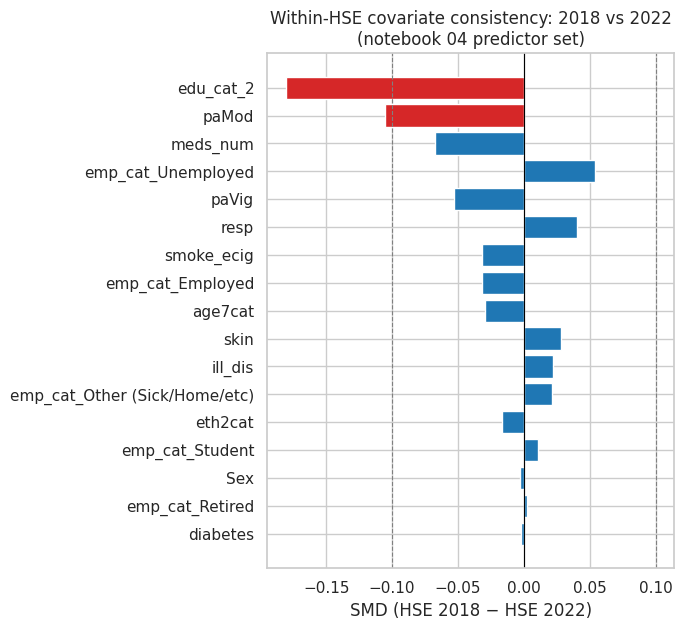

In [11]:
smds_plot = smd_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(7, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (HSE 2018 − HSE 2022)")
ax.set_title("Within-HSE covariate consistency: 2018 vs 2022\n(notebook 04 predictor set)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_hse_2018_vs_2022.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
valid = smd_series.dropna()
imbalanced = valid[valid.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(valid)}")

if len(imbalanced) == 0:
    print("\nAll predictor variables are well-balanced between HSE 2017 and HSE 2018.")
    print("Pooling the two waves as a single reference distribution for notebook 04 is supported.")
else:
    print("\nVariables exceeding |SMD| > 0.1 between HSE 2017 and HSE 2018:")
    display(imbalanced.round(3).to_frame())
    print("\nThese wave-specific differences should be acknowledged when interpreting")

Variables with |SMD| > 0.1: 2 / 17

Variables exceeding |SMD| > 0.1 between HSE 2017 and HSE 2018:


,SMD (2018 − 2022)
edu_cat_2,-0.181
paMod,-0.105



These wave-specific differences should be acknowledged when interpreting
